<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-03-08 20:33:05--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  40.1MB/s    in 3.7s    

2026-03-08 20:33:09 (40.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Load the data


In [4]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



null values before cleaning

 JobSatPoints_6    35987
JobSatPoints_7    35989
dtype: int64



null values after cleaning

 JobSatPoints_6    0
JobSatPoints_7    0
dtype: int64


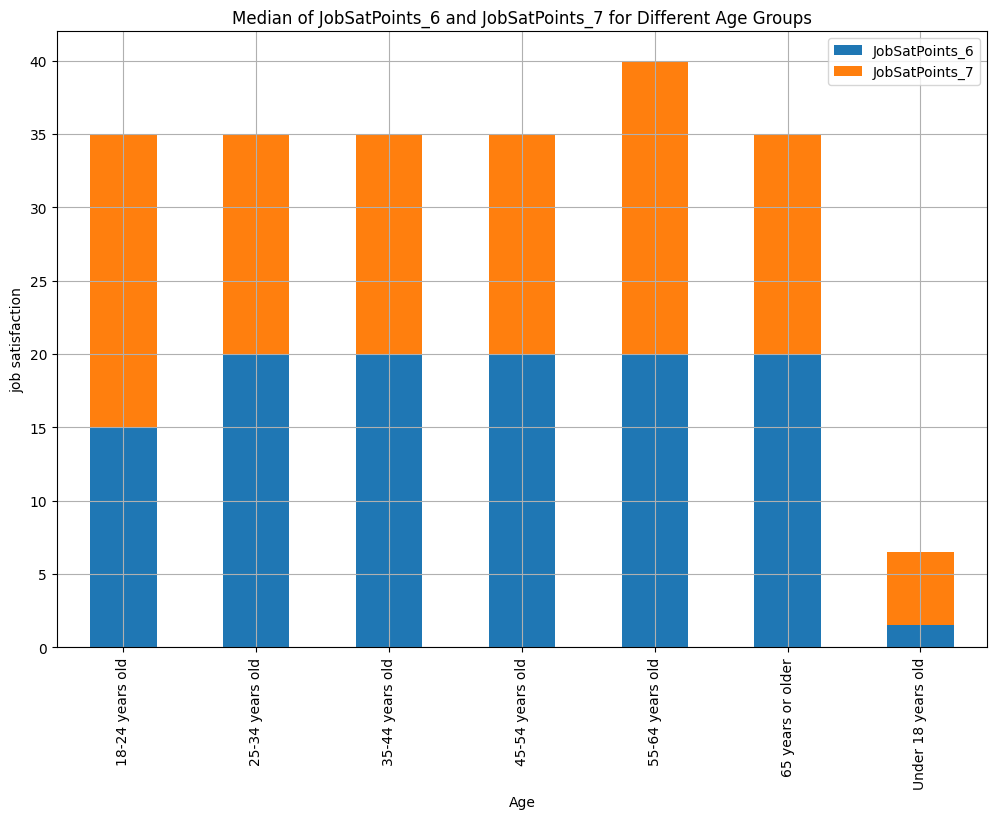

In [6]:
##Write your code here

age_sat=df[['JobSatPoints_6','JobSatPoints_7','Age']].copy()

print('null values before cleaning\n\n',age_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())
age_sat=age_sat.dropna(subset=['JobSatPoints_6','JobSatPoints_7'])
print('\n\n\nnull values after cleaning\n\n',age_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())

age_sat=age_sat[age_sat['Age']!='Prefer not to say']                                        # remove non-informative age responses

grouped_age_sat=age_sat.groupby('Age')[['JobSatPoints_6','JobSatPoints_7']].median()

grouped_age_sat.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,figsize=(12,8)
    ,title='Median of JobSatPoints_6 and JobSatPoints_7 for Different Age Groups'
    ,ylabel='job satisfaction'
)
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


null values before cleaning

 JobSatPoints_6    35987
JobSatPoints_7    35989
dtype: int64



null values after cleaning

 JobSatPoints_6    0
JobSatPoints_7    0
dtype: int64


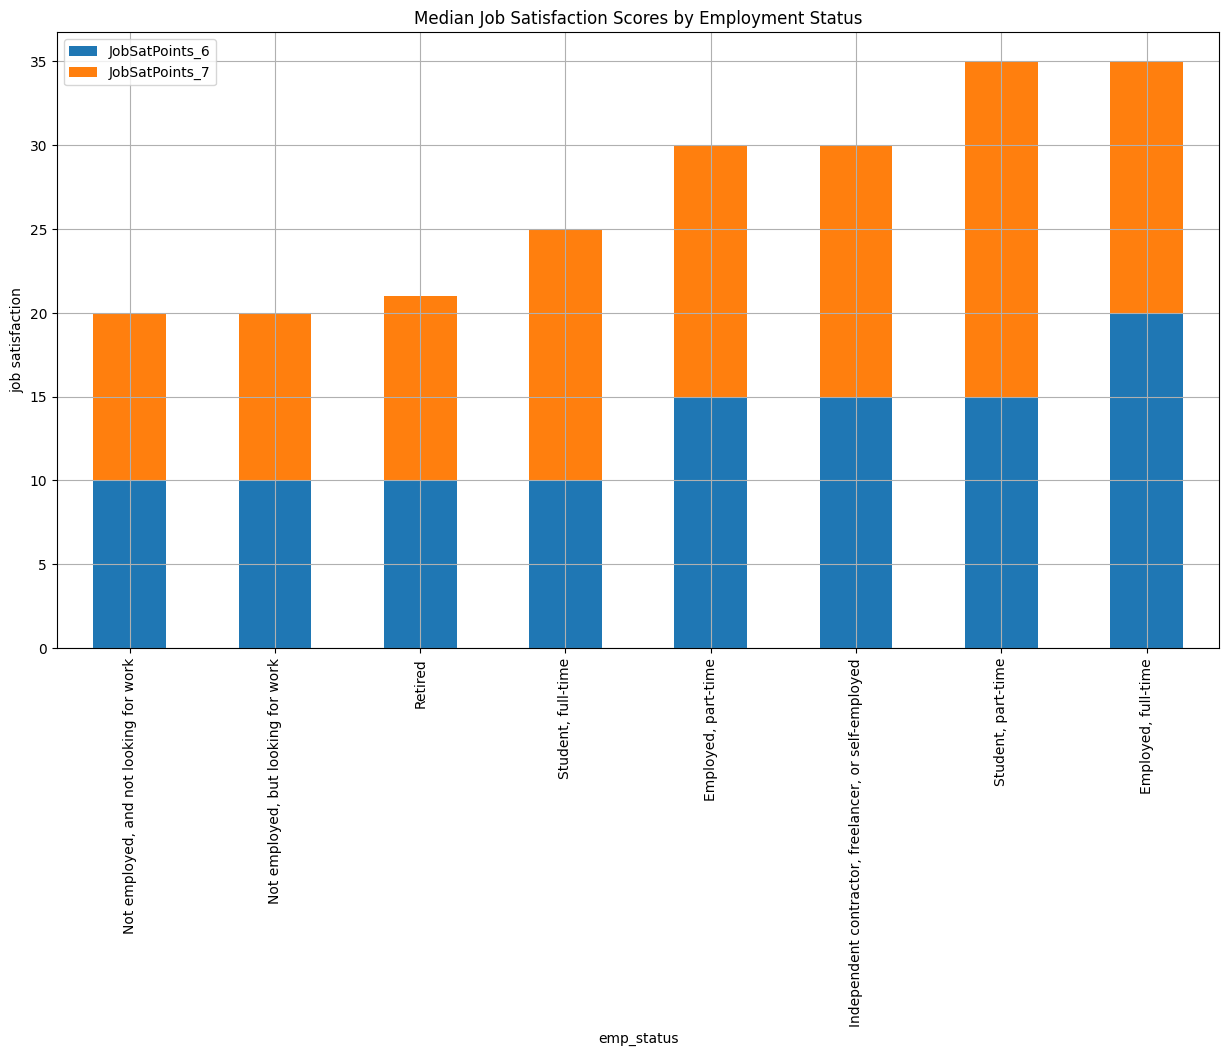

In [7]:
##Write your code here

employment_sat=df[['JobSatPoints_6','JobSatPoints_7','Employment']].copy()

print('null values before cleaning\n\n',employment_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())
employment_sat=employment_sat.dropna(subset=['JobSatPoints_6','JobSatPoints_7'])
print('\n\n\nnull values after cleaning\n\n',employment_sat[['JobSatPoints_6','JobSatPoints_7']].isnull().sum())

employment_sat['emp_status']=employment_sat['Employment'].str.split(';')
employment_sat=employment_sat.explode('emp_status')                               # split multiple employment statuses into separate rows

top10_emp_status=(
    employment_sat['emp_status'].value_counts()                                   # keep only the 10 most common employment statuses for clearer visualization
    .head(10).index
)

grouped_employment_sat=(
    employment_sat[employment_sat['emp_status'].isin(top10_emp_status)]
    .groupby('emp_status')[['JobSatPoints_6','JobSatPoints_7']].median()
    .sort_values(['JobSatPoints_6','JobSatPoints_7'])
)

grouped_employment_sat.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,figsize=(15,8)
    ,title='Median Job Satisfaction Scores by Employment Status'
    ,ylabel='job satisfaction'
)
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 25-44.


In [8]:
##Write your code here

comp_sat=df[['JobSatPoints_6','ConvertedCompYearly','Age']].copy()

print('null values before cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())
comp_sat=comp_sat.dropna(subset=['JobSatPoints_6','ConvertedCompYearly'])
print('\n\n\nnull values after cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())

Q1=np.quantile(comp_sat['ConvertedCompYearly'], 0.25)
Q3=np.quantile(comp_sat['ConvertedCompYearly'], 0.75)
IQR=Q3-Q1                                                                              # calculate IQR on the full dataset to remove global compensation outliers before comparing specific age groups

max_value=Q3+3*IQR                                                                    # use a wider IQR threshold (3*IQR) because compensation data is strongly right-skewed
min_value=Q1-1.5*IQR

comp_sat=comp_sat[
                    (comp_sat['ConvertedCompYearly']>min_value) &                       # Extreme compensation values were removed using the IQR method to improve visualization clarity
                    (comp_sat['ConvertedCompYearly']<max_value) &
                    (comp_sat['Age'].isin(['25-34 years old','35-44 years old']))
]

comp_sat['normalized_compensation']=(comp_sat['ConvertedCompYearly']/max_value)*100   # normalize compensation to a 0–100 scale to make it comparable with JobSatPoints_6 


grouped_comp_sat=comp_sat.groupby('Age')[['normalized_compensation','JobSatPoints_6']].median()

null values before cleaning

 JobSatPoints_6         35987
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSatPoints_6         0
ConvertedCompYearly    0
dtype: int64


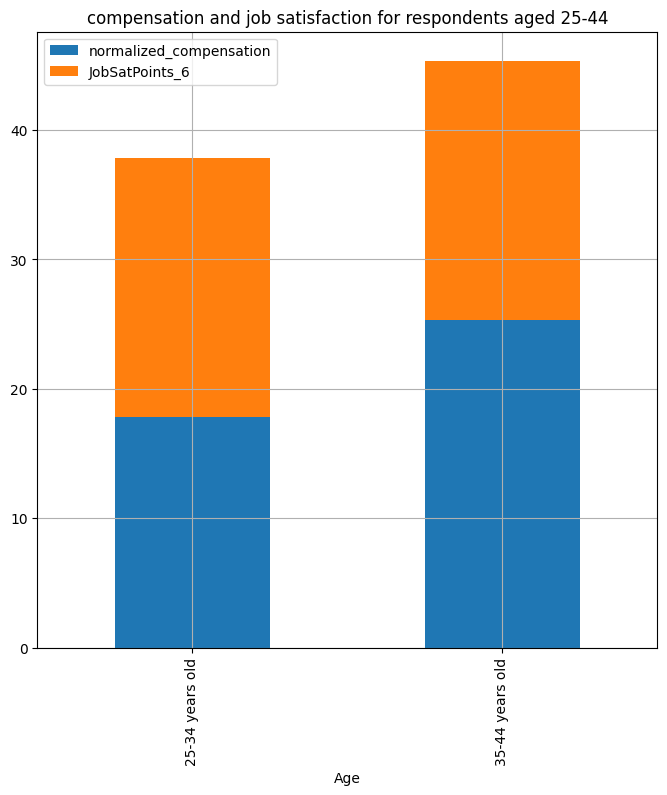

In [9]:
grouped_comp_sat.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,figsize=(8,8)
    ,title='compensation and job satisfaction for respondents aged 25-44'
)
plt.show()    

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


null values before cleaning

 JobSatPoints_6         35987
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSatPoints_6         0
ConvertedCompYearly    0
dtype: int64


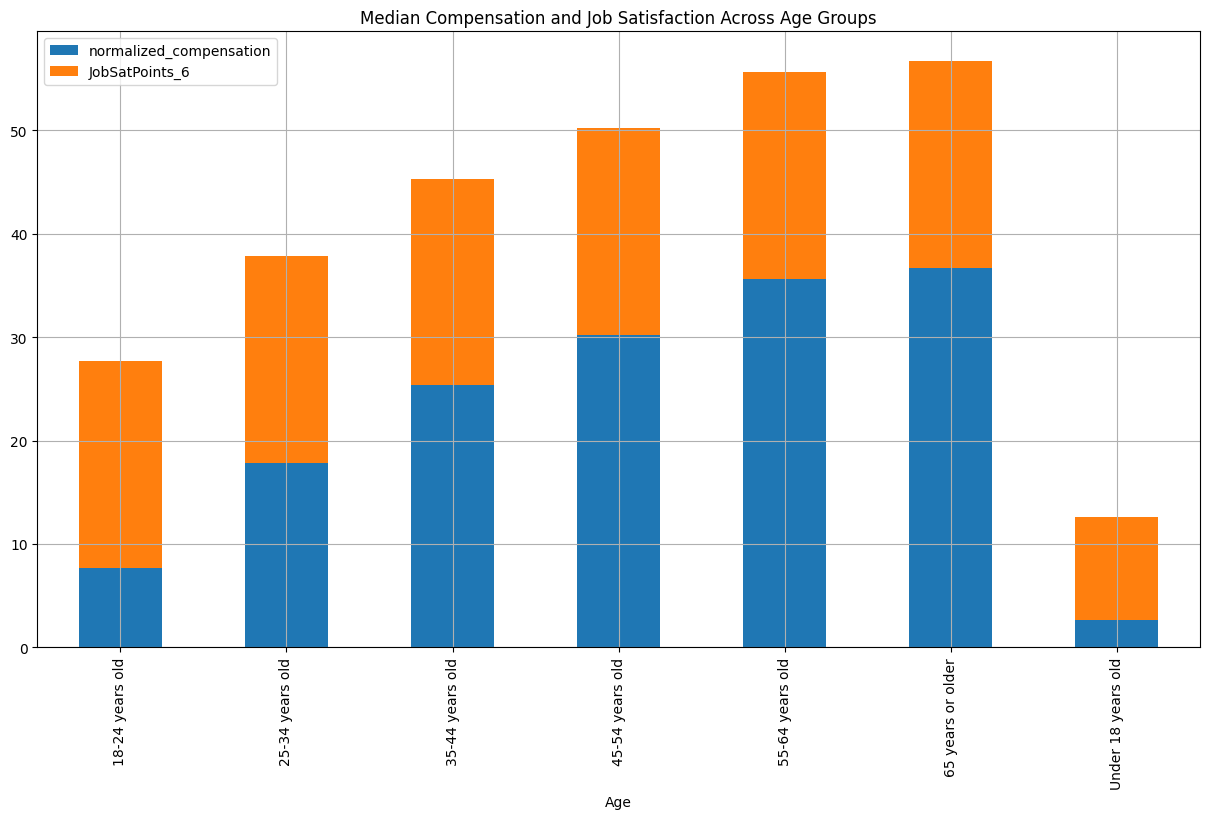

In [10]:
##Write your code here

comp_sat2=df[['JobSatPoints_6','ConvertedCompYearly','Age']].copy()

print('null values before cleaning\n\n',comp_sat2[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())
comp_sat2=comp_sat2.dropna(subset=['JobSatPoints_6','ConvertedCompYearly'])
print('\n\n\nnull values after cleaning\n\n',comp_sat2[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())

comp_sat2=comp_sat2[comp_sat2['Age']!='Prefer not to say']                           # remove non-informative age responses

Q1=np.quantile(comp_sat2['ConvertedCompYearly'], 0.25)
Q3=np.quantile(comp_sat2['ConvertedCompYearly'], 0.75)
IQR=Q3-Q1

max_value=Q3+3*IQR                                                                    # use a wider IQR threshold (3*IQR) because compensation data is strongly right-skewed
min_value=Q1-1.5*IQR

comp_sat2=comp_sat2[
                    (comp_sat2['ConvertedCompYearly']>min_value) &
                    (comp_sat2['ConvertedCompYearly']<max_value)
]

comp_sat2['normalized_compensation']=(comp_sat2['ConvertedCompYearly']/max_value)*100   # normalize compensation to a 0–100 scale to make it comparable with JobSatPoints_6 


grouped_comp_sat2=comp_sat2.groupby('Age')[['normalized_compensation','JobSatPoints_6']].median()

grouped_comp_sat2.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,figsize=(15,8)
    ,title='Median Compensation and Job Satisfaction Across Age Groups'
)
plt.show()  

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [11]:
##Write your code here

age_db=df[['DatabaseWantToWorkWith','Age']].copy()

print('null values before cleaning',age_db['DatabaseWantToWorkWith'].isnull().sum())
age_db=age_db.dropna(subset=['DatabaseWantToWorkWith'])
print('\n\nnull values after cleaning',age_db['DatabaseWantToWorkWith'].isnull().sum())

age_db=age_db[age_db['Age']!='Prefer not to say']                              # remove non-informative age responses

age_db['wanted_db']=age_db['DatabaseWantToWorkWith'].str.split(';')
age_db=age_db.explode('wanted_db')                                             # split multiple database responses into separate rows

top6_db=(
    age_db['wanted_db'].value_counts()                                          # keep the six most frequently desired databases for clearer visualization
    .head(6).index
)

age_db=age_db[age_db['wanted_db'].isin(top6_db)].reset_index(drop=True)

age_db_cross=pd.crosstab(index=age_db['Age'], columns=age_db['wanted_db'])
print(age_db_cross.sum(axis=1))

age_db_cross_norm=age_db_cross.div(age_db_cross.sum(axis=1),axis=0) # convert counts to proportions within each age group
age_db_cross_norm=age_db_cross_norm[top6_db]                          # reorder columns according to popularity

null values before cleaning 22879


null values after cleaning 0
Age
18-24 years old       17619
25-34 years old       30421
35-44 years old       18468
45-54 years old        7483
55-64 years old        2650
65 years or older       551
Under 18 years old     2075
dtype: int64


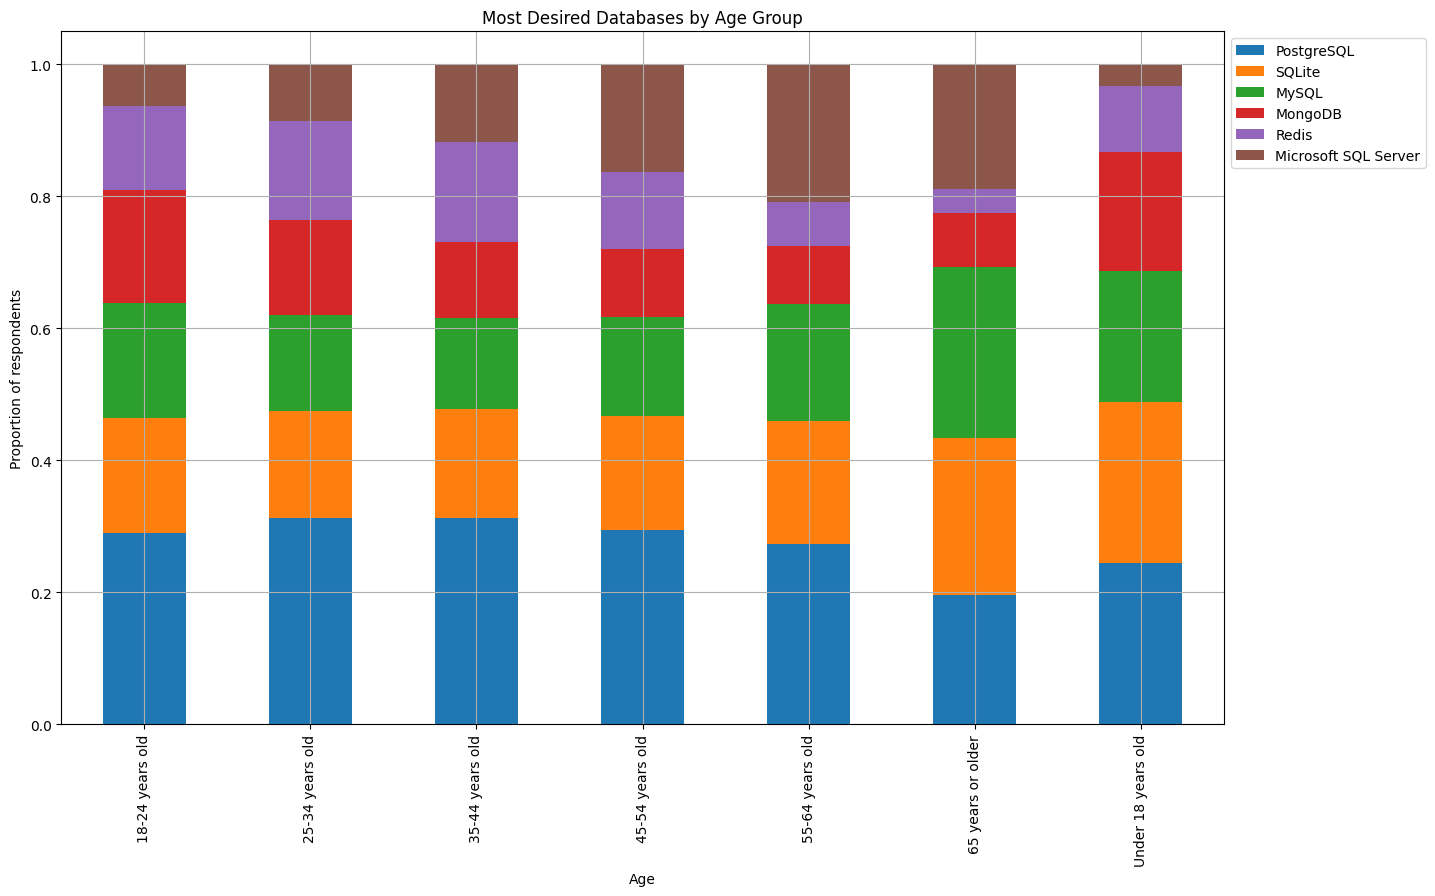

In [12]:
age_db_cross_norm.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,legend=True
    ,figsize=(15,9)
    ,ylabel='Proportion of respondents'
    ,title='Most Desired Databases by Age Group'
)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [13]:
##Write your code here

employment_sat2=df[['JobSat','Employment']].copy()

print('null values before cleaning\n\n',employment_sat2['JobSat'].isnull().sum())
employment_sat2=employment_sat2.dropna(subset=['JobSat'])
print('\n\n\nnull values after cleaning\n\n',employment_sat2['JobSat'].isnull().sum())

employment_sat2['emp_status']=employment_sat2['Employment'].str.split(';')
employment_sat2=employment_sat2.explode('emp_status')                                     # split multiple employment statuses into separate rows

top6_emp_status=(
    employment_sat2['emp_status'].value_counts()                                          # keep the six most common employment types for clearer visualization
    .head(6).index
)

employment_sat2=employment_sat2[employment_sat2['emp_status'].isin(top6_emp_status)].reset_index(drop=True)

employment_sat_cross=pd.crosstab(index=employment_sat2['JobSat'], columns=employment_sat2['emp_status'])

employment_sat_cross_norm=employment_sat_cross.div(employment_sat_cross.sum(axis=1),axis=0)                   # convert counts to proportions within each job satisfaction level

employment_sat_cross

null values before cleaning

 36311



null values after cleaning

 0


emp_status,"Employed, full-time","Employed, part-time","Independent contractor, freelancer, or self-employed","Not employed, but looking for work","Student, full-time","Student, part-time"
JobSat,,,,,,
0.0,282,19,40,6,7,18
1.0,243,28,37,5,10,12
2.0,695,54,102,9,26,44
3.0,1045,84,144,13,52,54
4.0,1006,87,167,9,44,53
5.0,1760,134,269,20,66,64
6.0,3413,250,489,15,149,138
7.0,5770,388,853,25,232,175
8.0,6771,436,1101,12,254,234


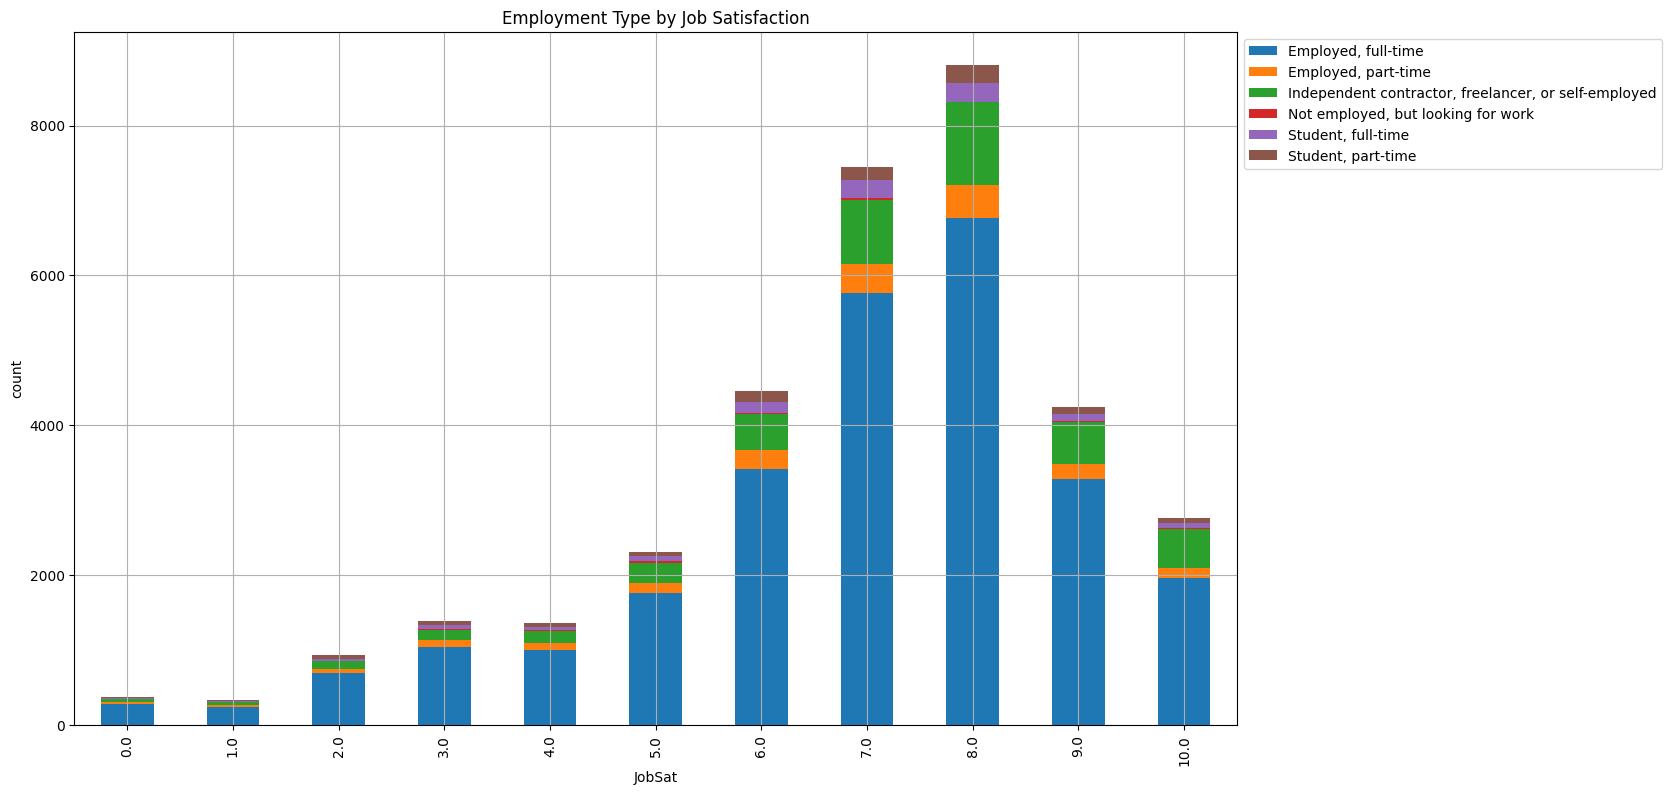

In [14]:
employment_sat_cross.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,legend=True
    ,figsize=(15,9)
    ,ylabel='count'
    ,title='Employment Type by Job Satisfaction'
)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

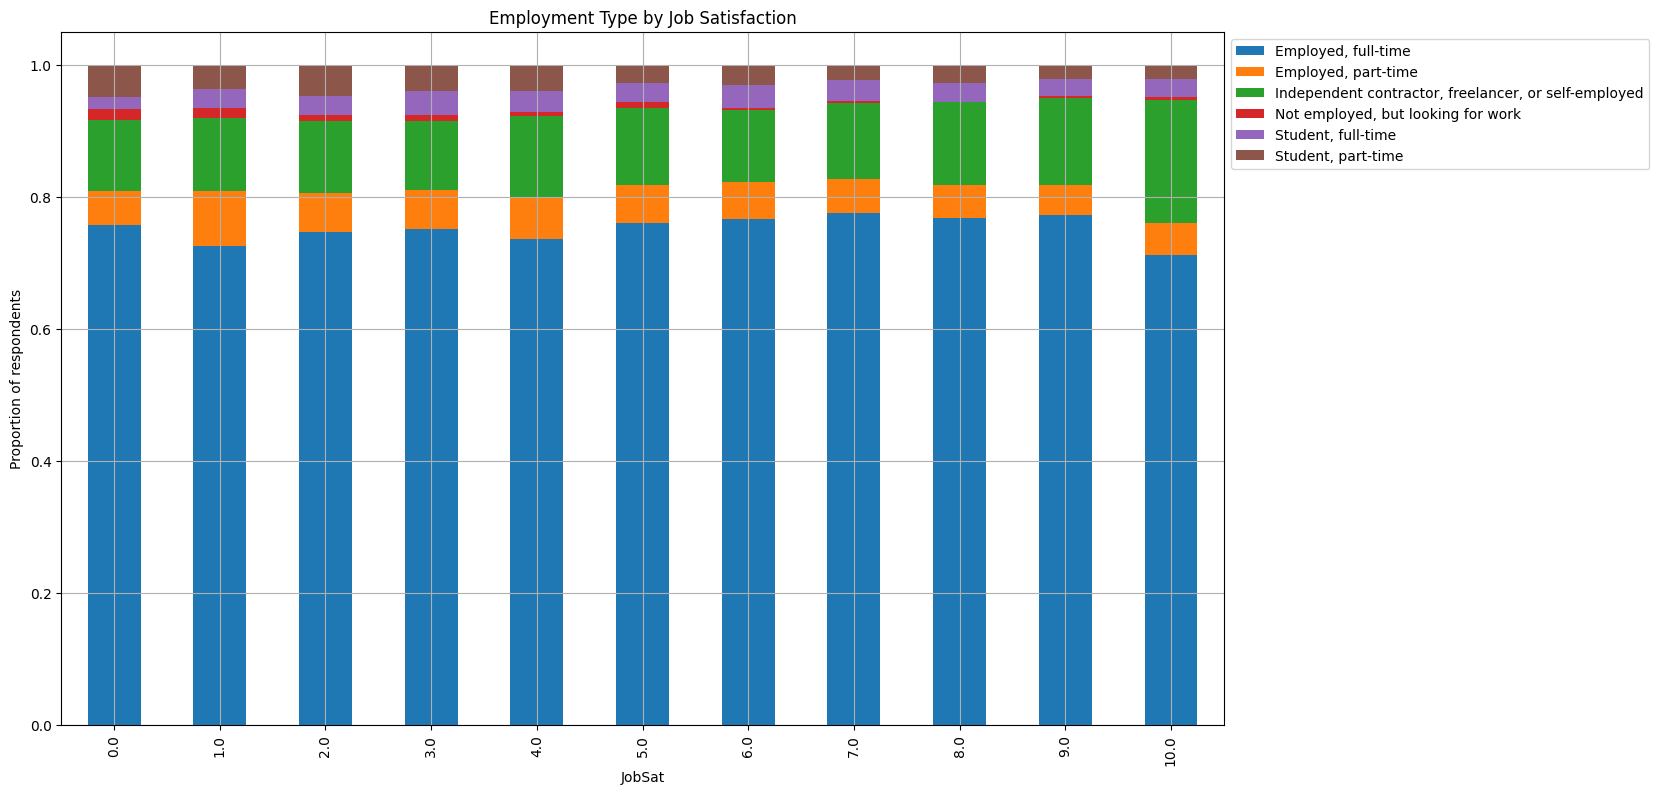

In [15]:
employment_sat_cross_norm.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,legend=True
    ,figsize=(15,9)
    ,ylabel='Proportion of respondents'
    ,title='Employment Type by Job Satisfaction'
)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [16]:
##Write your code here

age_admired_lang=df[['LanguageAdmired','Age']].copy()

print('null values before cleaning',age_admired_lang['LanguageAdmired'].isnull().sum())
age_admired_lang=age_admired_lang.dropna(subset=['LanguageAdmired'])
print('\n\nnull values after cleaning',age_admired_lang['LanguageAdmired'].isnull().sum())

age_admired_lang=age_admired_lang[age_admired_lang['Age']!='Prefer not to say']                   # remove non-informative age responses

age_admired_lang['language']=age_admired_lang['LanguageAdmired'].str.split(';')                   # split multiple language responses into separate rows
age_admired_lang=age_admired_lang.explode('language')

top6_lang=(
    age_admired_lang['language'].value_counts()                                                   # keep the six most admired programming languages for clearer visualization
    .head(6).index
)

age_admired_lang=age_admired_lang[age_admired_lang['language'].isin(top6_lang)].reset_index(drop=True)

age_lang_cross=pd.crosstab(index=age_admired_lang['Age'], columns=age_admired_lang['language'])
print(age_lang_cross.sum(axis=1))

age_lang_cross_norm=age_lang_cross.div(age_lang_cross.sum(axis=1),axis=0)  # convert counts to proportions within each age group
age_lang_cross_norm=age_lang_cross_norm[top6_lang]                           # reorder columns according to popularity

null values before cleaning 14565


null values after cleaning 0
Age
18-24 years old       24565
25-34 years old       41011
35-44 years old       25825
45-54 years old       10573
55-64 years old        4185
65 years or older       900
Under 18 years old     4526
dtype: int64


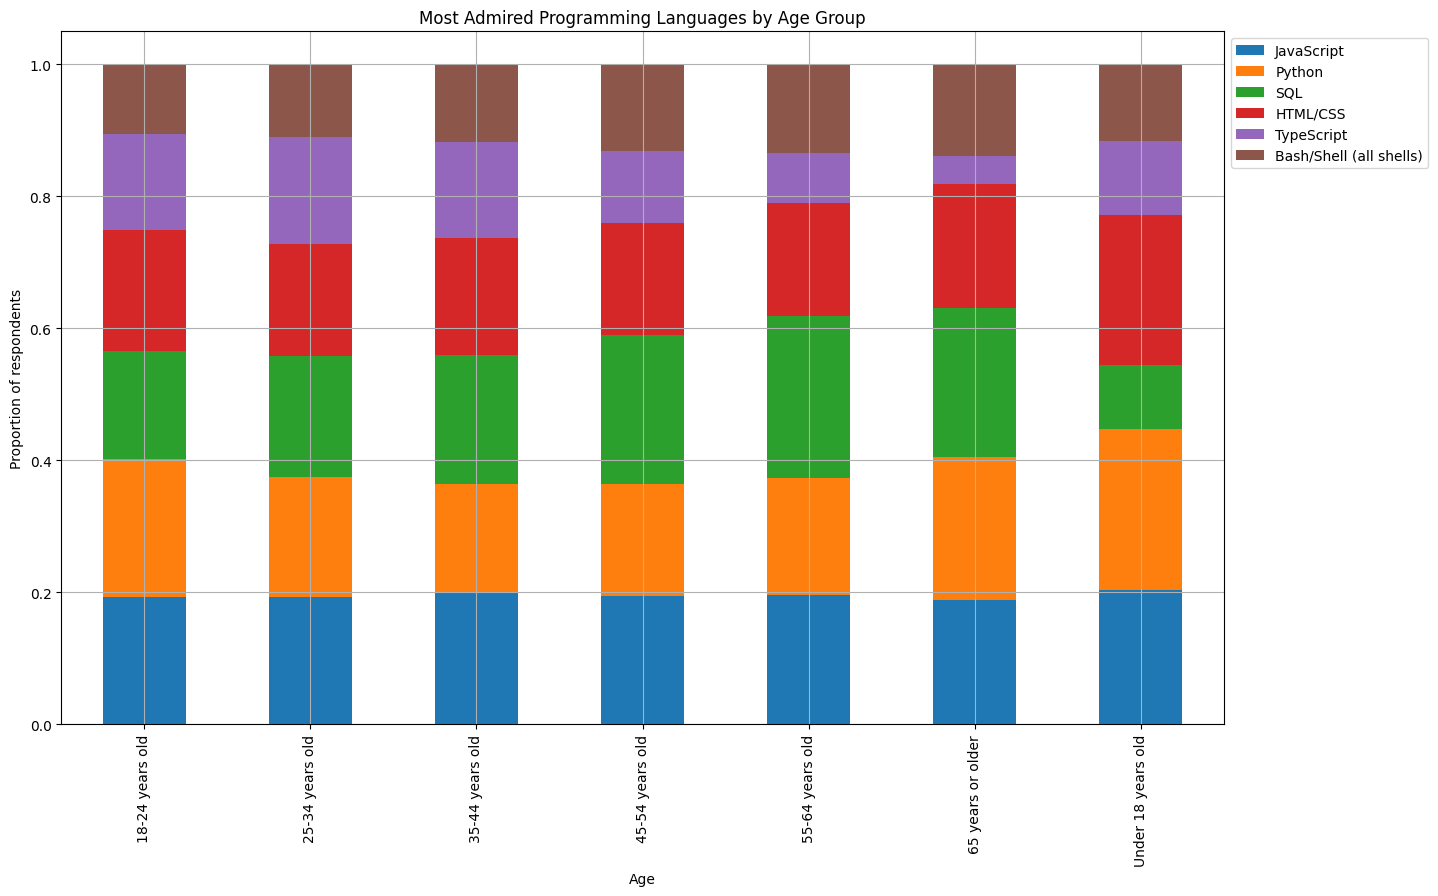

In [17]:
age_lang_cross_norm.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,legend=True
    ,figsize=(15,9)
    ,ylabel='Proportion of respondents'
    ,title='Most Admired Programming Languages by Age Group'
)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [18]:
##Write your code here

employment_platform=df[['PlatformAdmired','Employment']].copy()

print('null values before cleaning',employment_platform['PlatformAdmired'].isnull().sum())
employment_platform=employment_platform.dropna(subset=['PlatformAdmired'])
print('\n\nnull values after cleaning',employment_platform['PlatformAdmired'].isnull().sum())

employment_platform['platform']=employment_platform['PlatformAdmired'].str.split(';')                # split multiple platform responses into separate rows
employment_platform=employment_platform.explode('platform')

top6_platforms=(
    employment_platform['platform'].value_counts()                                                   # keep the six most admired platforms for clearer visualization
    .head(6).index
)

employment_platform=employment_platform[employment_platform['platform'].isin(top6_platforms)]

employment_platform['employment_status']=employment_platform['Employment'].str.split(';')            # split multiple employment statuses into separate rows
employment_platform=employment_platform.explode('employment_status')

top6_employment=(
    employment_platform['employment_status'].value_counts()                                          # keep only the 6 most common employment statuses for clearer visualization
    .head(6).index
)

employment_platform=employment_platform[employment_platform['employment_status'].isin(top6_employment)].reset_index(drop=True)

employment_platform_cross=pd.crosstab(index=employment_platform['employment_status'], columns=employment_platform['platform'])
employment_platform_cross_norm=employment_platform_cross.div(employment_platform_cross.sum(axis=1),axis=0)               # convert counts to proportions
employment_platform_cross_norm=employment_platform_cross_norm[top6_platforms]                                            # reorder columns according to popularity
employment_platform_cross

null values before cleaning 34060


null values after cleaning 0


platform,Amazon Web Services (AWS),Cloudflare,Firebase,Google Cloud,Microsoft Azure,Vercel
employment_status,,,,,,
"Employed, full-time",11336,3042,2283,4650,6329,1853
"Employed, part-time",643,361,261,403,364,312
"Independent contractor, freelancer, or self-employed",2733,1346,953,1454,1417,834
"Not employed, but looking for work",639,290,302,376,232,362
"Student, full-time",808,788,544,677,409,749
"Student, part-time",400,218,189,276,249,221


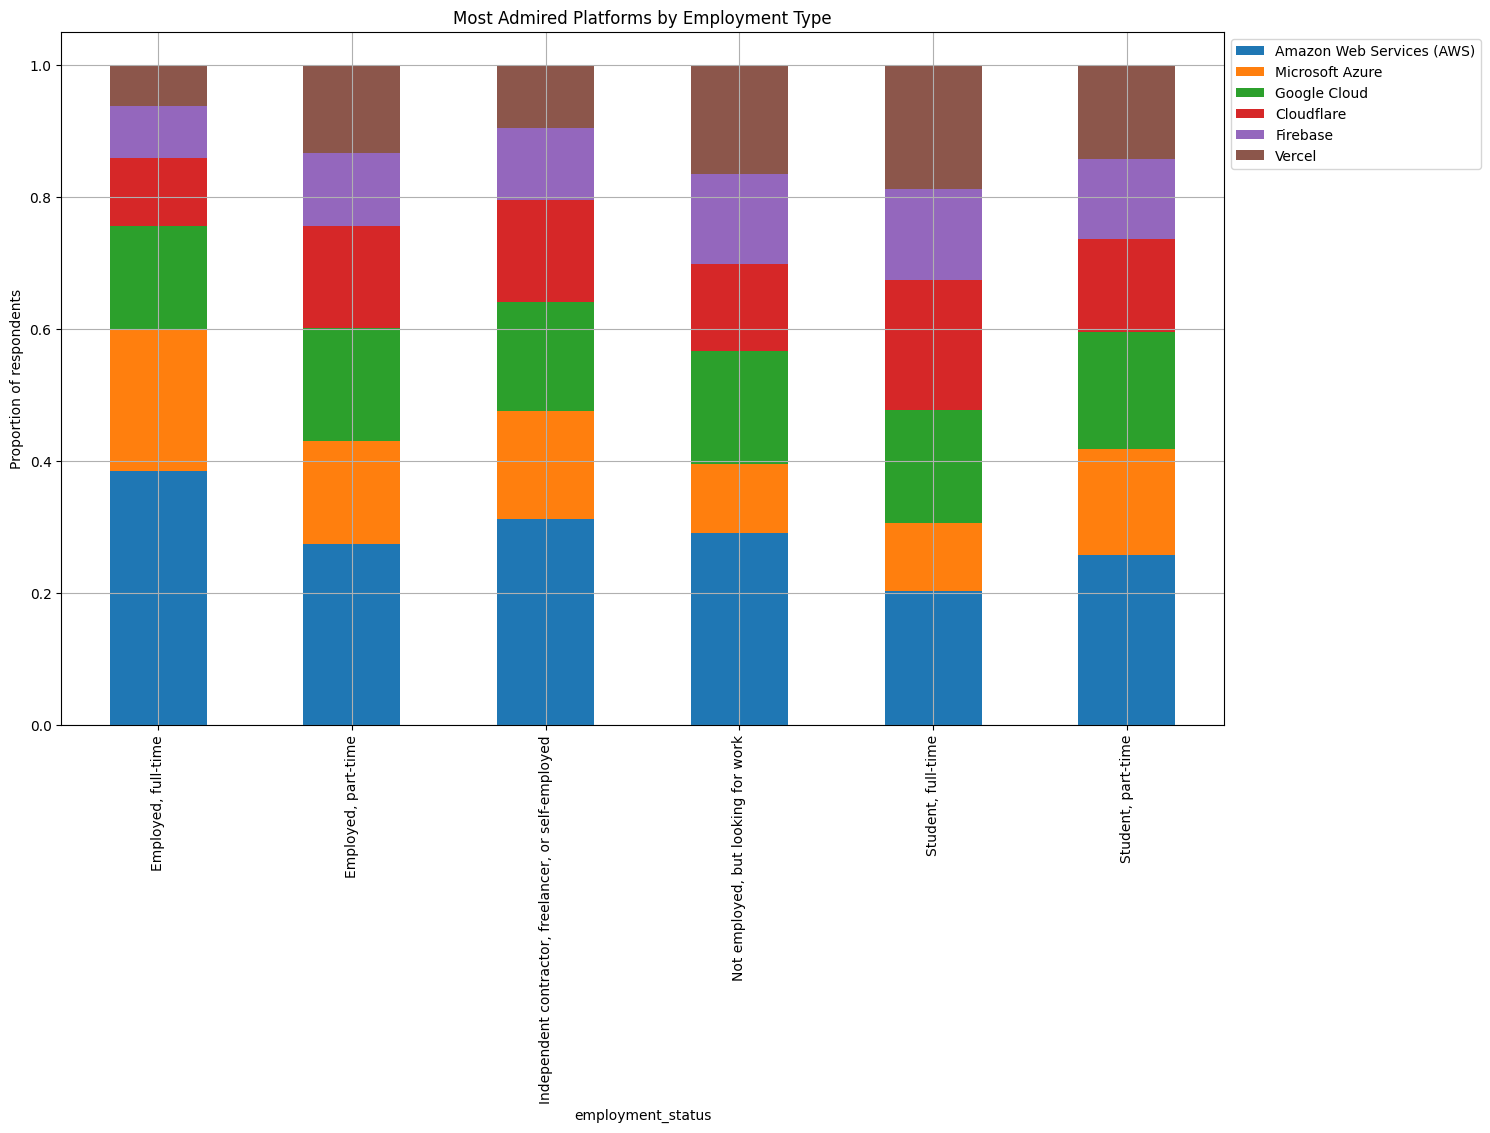

In [19]:
employment_platform_cross_norm.plot(
    kind='bar'
    ,stacked=True
    ,grid=True
    ,legend=True
    ,figsize=(15,9)
    ,ylabel='Proportion of respondents'
    ,title='Most Admired Platforms by Employment Type'
)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
